# Fraud Detection Project

Develop a robust machine learning model to accurately predict fraudulent transactions.

# Project Overview:
This project aims to enhance the accuracy of detecting fraud in mobile financial transactions. By leveraging machine learning, the project seeks to predict fraudulent transactions with high precision. The goal is to develop a robust machine learning model to accurately identify fraudulent transactions in real-time , enabling the company to improve security, reduce financial losses, and gain insights into factors contributing to transaction fraud.

# Implementation Steps

In [177]:
#Importing necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# a. Data Collection



*   Acquired a dataset (Fraud_Analysis_Dataset.csv) containing mobile financial transactions.
*   Dataset included:

      *   Feature labels such as step, type, amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
      *  Target label as isFraud

*   Dataset size ~11,142 records







In [178]:
#Loading the Dataset
df = pd.read_csv("/content/Fraud_Analysis_Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


# b. Data Pre-processing

Clean, transform, and prepare the data for ML model learning.

In [179]:
#Inspecting dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [180]:
#Checking the missing values
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [181]:
# Dropping nameOrig and nameDest as they are just IDs
df = df.drop(columns=["nameOrig", "nameDest"], errors="ignore")

In [182]:
#Engineering new feautures
df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]
df[["balance_diff_orig","balance_diff_dest"]].head()

,balance_diff_orig,balance_diff_dest
0,181.0,0.0
1,181.0,-21182.0
2,2806.0,0.0
3,2806.0,-26202.0
4,20128.0,0.0


In [183]:
#Encoding of categorial types here it is type
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])
df["type"].unique()

array([4, 1, 3, 2, 0])

In [184]:
#Performing standard scaler numeric feautures were normalized

from sklearn.preprocessing import StandardScaler


# List of columns to scale
x = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_diff_orig",
    "balance_diff_dest"
]

# Initializing Standardscaler
scaler = StandardScaler()

# Fit and transform these columns
df[x] = scaler.fit_transform(df[x])

# Checking the result
df[x].head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff_orig,balance_diff_dest
0,-0.280266,-0.431160,-0.394754,-0.341509,-0.369918,-0.131462,-0.192218
1,-0.280266,-0.431160,-0.394754,-0.333366,-0.369918,-0.131462,-0.211168
2,-0.276812,-0.429935,-0.394754,-0.341509,-0.369918,-0.127976,-0.192218
3,-0.276812,-0.429935,-0.394754,-0.331436,-0.369918,-0.127976,-0.215659
4,-0.254021,-0.421852,-0.394754,-0.341509,-0.369918,-0.104969,-0.192218


In [185]:
df[x].describe()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balance_diff_orig,balance_diff_dest
count,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000,11142.000000
mean,-6.122070e-17,3.571207e-17,1.275431e-18,1.402974e-17,-6.249613e-17,0.000000,0.000000
std,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045,1.000045
min,-2.805006e-01,-4.312445e-01,-3.947543e-01,-3.415093e-01,-3.699180e-01,-1.499869,-11.911880
25%,-2.739953e-01,-4.310452e-01,-3.947543e-01,-3.415093e-01,-3.699180e-01,-0.131703,-0.192218
50%,-2.584503e-01,-4.180990e-01,-3.926390e-01,-3.415093e-01,-3.699180e-01,-0.130112,-0.192218
75%,-7.743752e-02,-2.893413e-01,-3.414417e-01,-2.372692e-01,-2.630757e-01,-0.119991,-0.190441
max,1.287686e+01,8.855201e+00,5.825936e+00,1.234465e+01,1.123181e+01,13.201962,16.179363


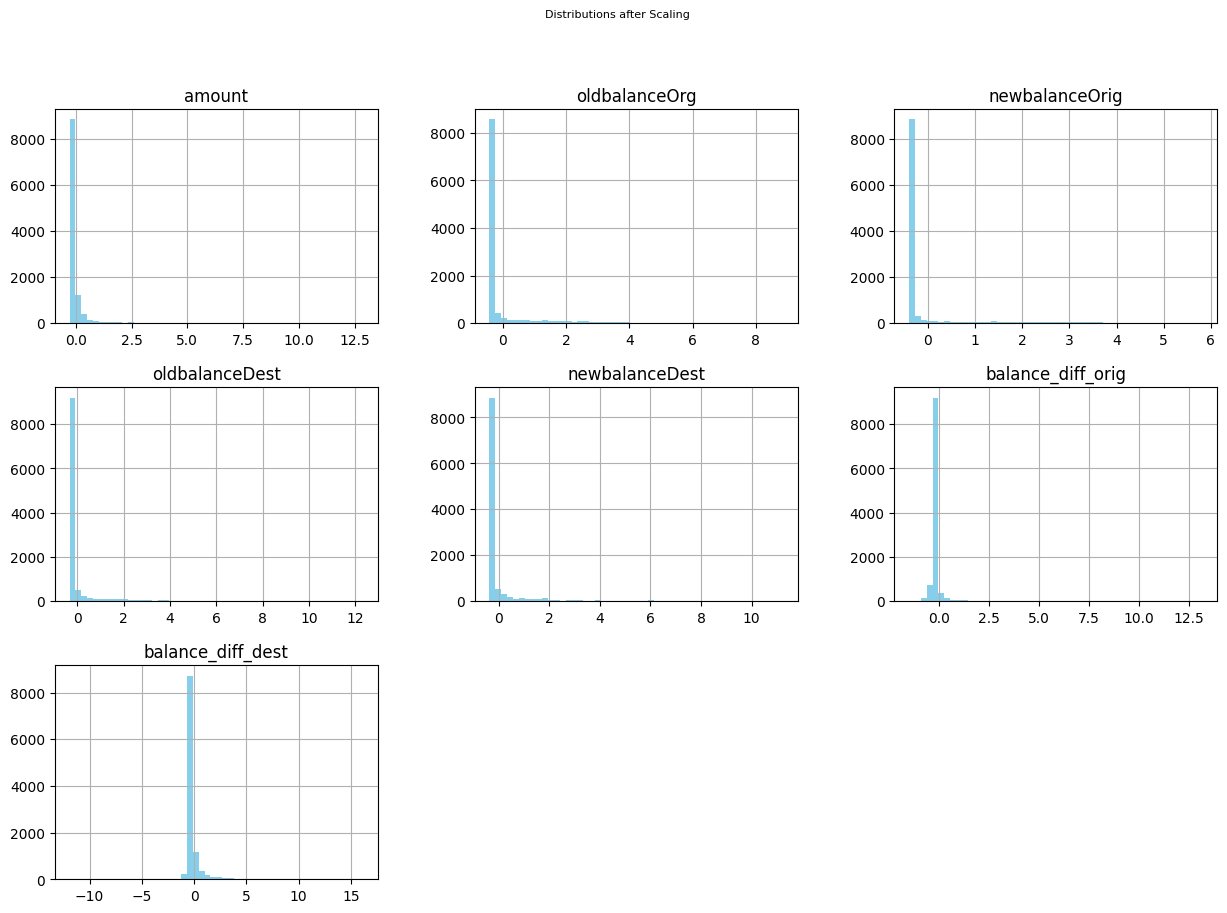

In [186]:
df[x].hist(figsize=(15,10), bins=50, color="skyblue")
plt.suptitle("Distributions after Scaling", fontsize=8)
plt.savefig("DistributionsafterScaling", dpi=300)
plt.show()

In [187]:
#Downloading the dataset after normalization for reference
df.to_csv("fraud_dataset_scaled.csv", index=False)
print("dataset after scaling is downloaded successfully")

dataset after scaling is downloaded successfully


In [188]:
#Splitting the Dataset
from sklearn.model_selection import train_test_split

# Features (excluding the target)
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

# Splitting 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (8913, 9)
Test set shape: (2229, 9)


In [189]:
#Used SMOTE to balance the training set due to class imbalance.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Confirm new class balance
y_train.value_counts()
y_train_res.value_counts()

,count
isFraud,
1,7999
0,7999


# c. Exploratory Data Analysis (EDA)

Understand patterns, detect anomalies, and inform feature engineering.




*   Categorical variables: type, isFraud
*  Continuous numeric variables: amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
*   Discrete numeric: step

/tmp/ipython-input-190-1032659379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="isFraud", data=df, palette="pastel")


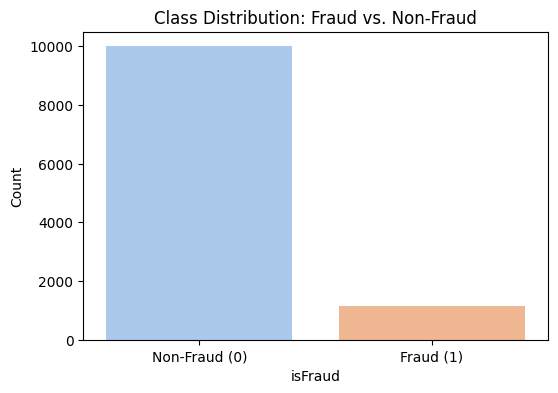

In [190]:
import matplotlib.pyplot as plt
import seaborn as sns

#Categorical Variables Distribution - isFraud Counts
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=df, palette="pastel")
plt.title("Class Distribution: Fraud vs. Non-Fraud")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.xticks([0,1], ["Non-Fraud (0)", "Fraud (1)"])
plt.savefig("ClassDistribution:FraudvsNon-Fraud", dpi=300)
plt.show()

/tmp/ipython-input-191-3748150952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=df, palette="pastel")


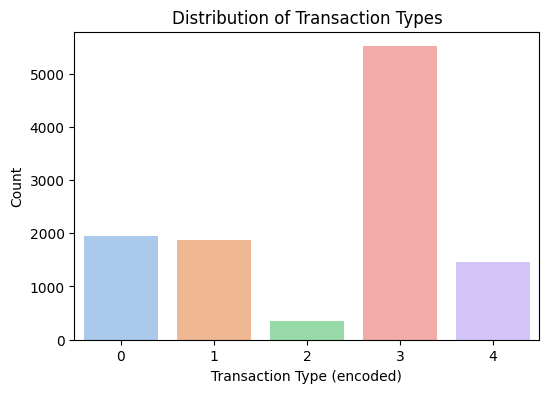

In [191]:
#Categorical Variables Distribution - Transaction Type Counts
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df, palette="pastel")
plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type (encoded)")
plt.ylabel("Count")
plt.savefig("DistributionofTransactionTypes", dpi=300)
plt.show()

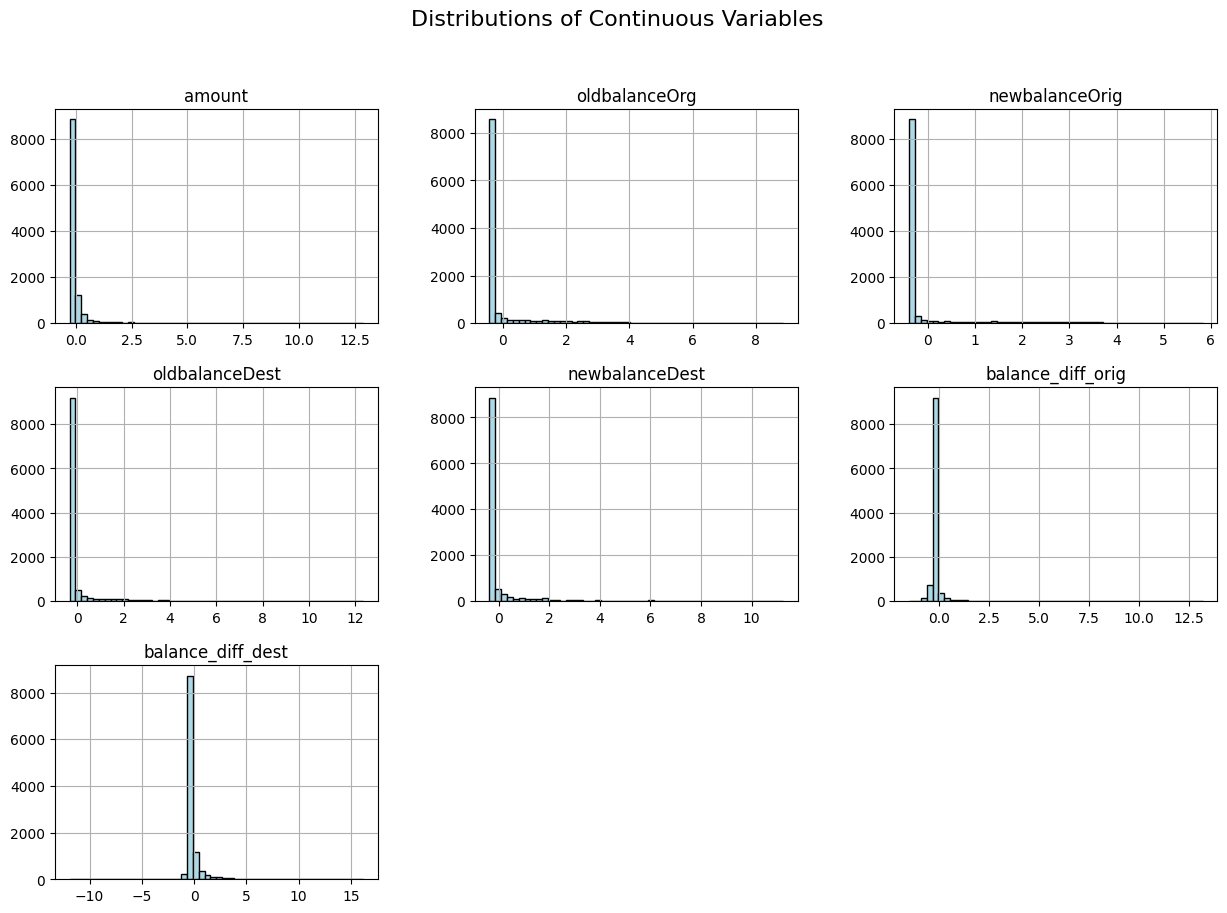

In [192]:
#Continuous Variables Distribution - Histograms plots of each numeric variable
x = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_diff_orig",
    "balance_diff_dest"
]

df[x].hist(
    figsize=(15,10),
    bins=50,
    color="lightblue",
    edgecolor="black"
)
plt.suptitle("Distributions of Continuous Variables", fontsize=16)
plt.savefig("DistributionsofContinuousVariables", dpi=300)
plt.show()

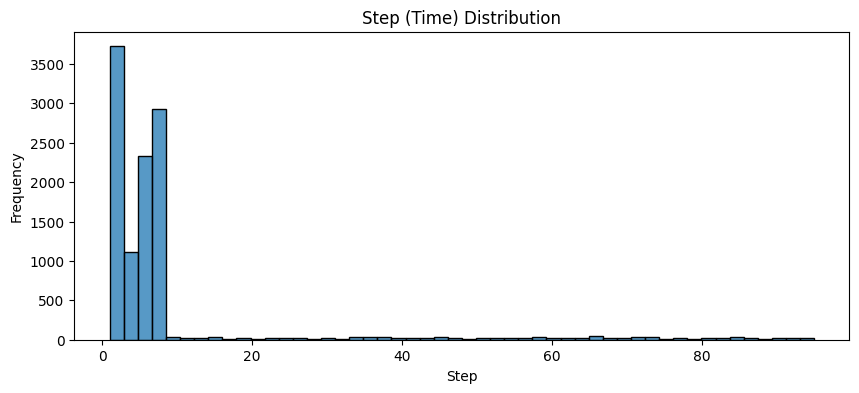

In [193]:
#Discrete Variable Distribution - Step variable
plt.figure(figsize=(10,4))
sns.histplot(df["step"], bins=50)
plt.title("Step (Time) Distribution")
plt.xlabel("Step")
plt.ylabel("Frequency")
plt.savefig("stepDistribution", dpi=300)
plt.show()

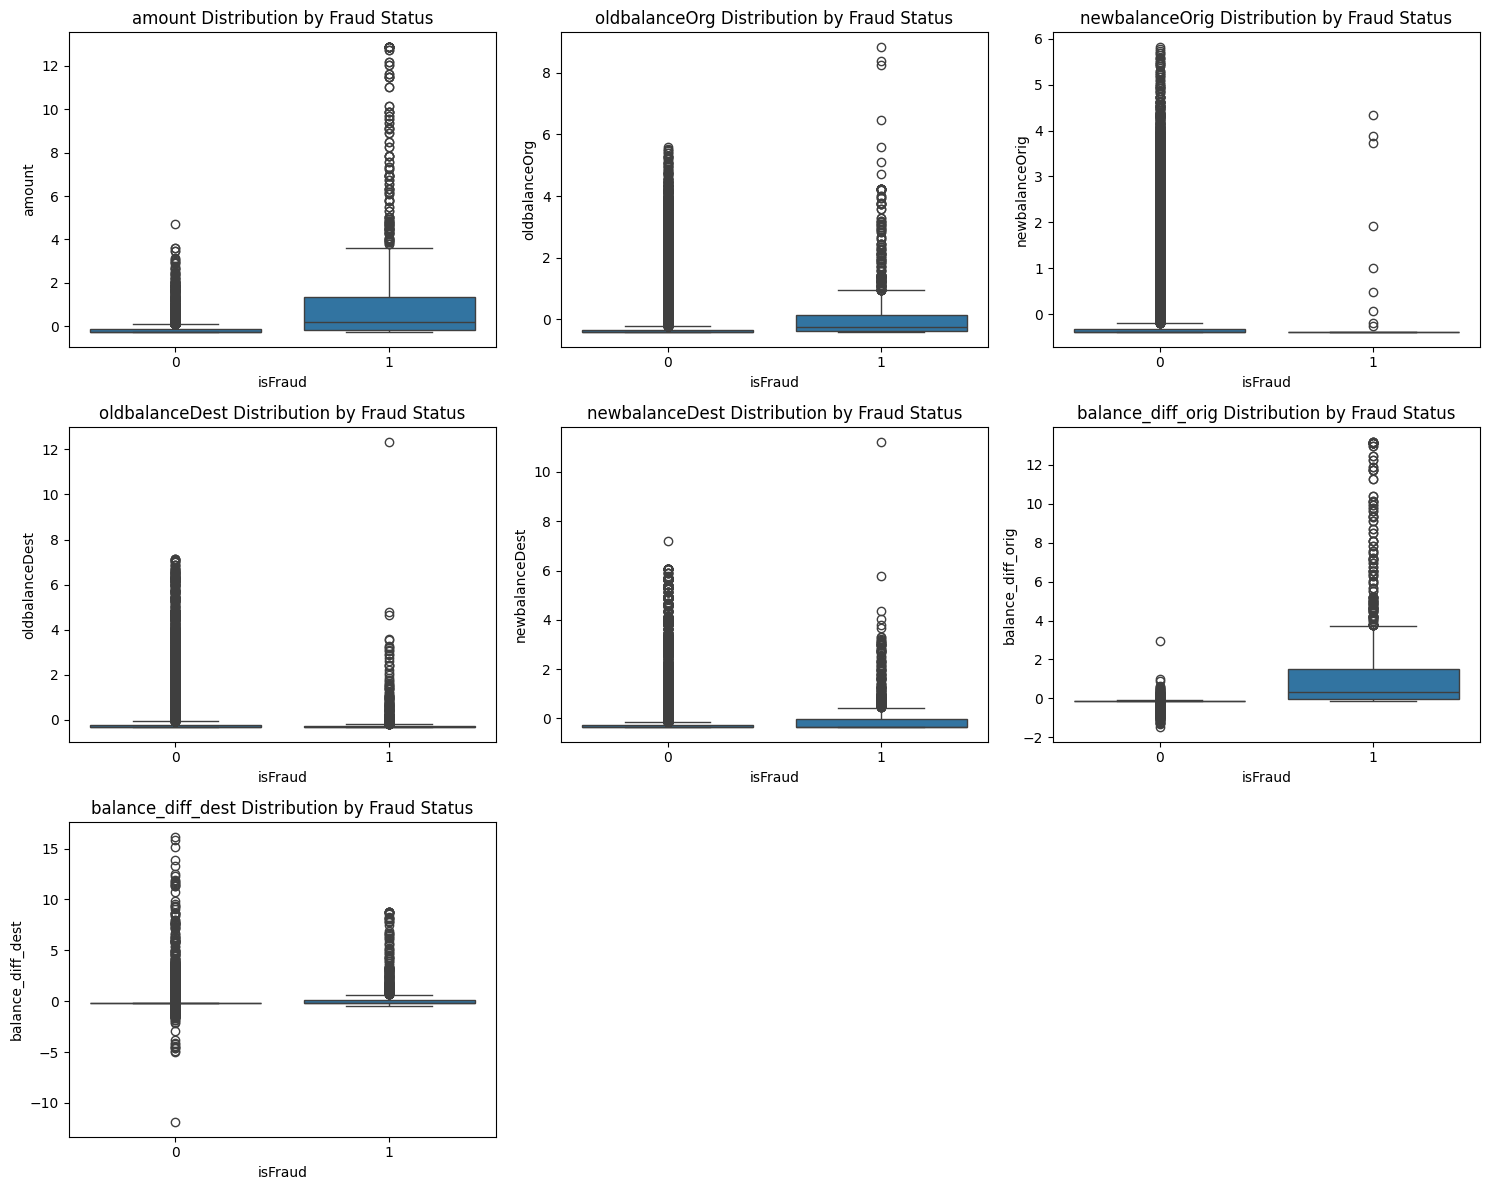

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Number of columns to display per row
cols_per_row = 3

# Total number of features
num_features = len(x)

# Compute number of rows needed
num_rows = math.ceil(num_features / cols_per_row)

# Create subplots grid
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=cols_per_row,
    figsize=(5 * cols_per_row, 4 * num_rows)
)

# Flatten axes array for easy iteration
axes = axes.flatten()

# Generate each boxplot
for i, col in enumerate(x):
    sns.boxplot(
        x="isFraud",
        y=col,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} Distribution by Fraud Status")
    axes[i].set_xlabel("isFraud")
    axes[i].set_ylabel(col)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Save to one image
plt.savefig("Boxplots_Side_by_Side.png", dpi=300)

# Display
plt.show()

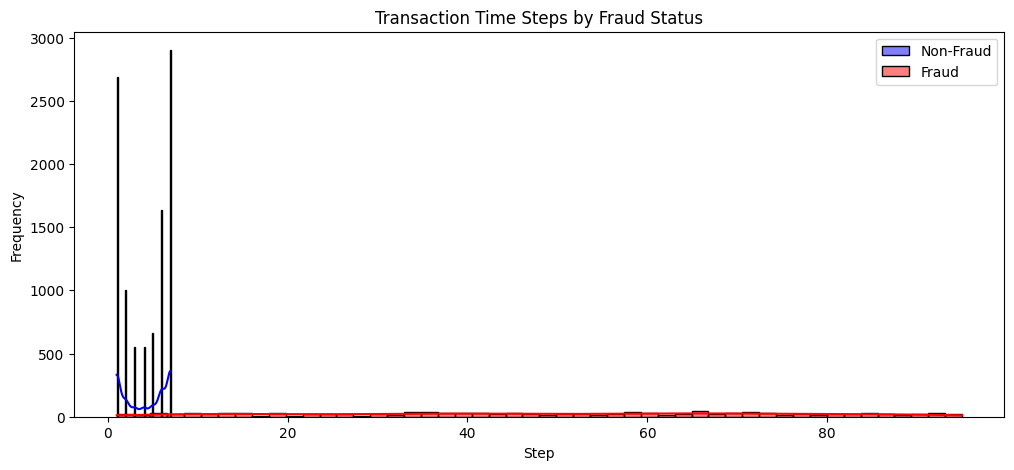

In [195]:
#Histogram of time steps
plt.figure(figsize=(12,5))
sns.histplot(
    df[df["isFraud"]==0]["step"],
    bins=50,
    color="blue",
    label="Non-Fraud",
    kde=True
)
sns.histplot(
    df[df["isFraud"]==1]["step"],
    bins=50,
    color="red",
    label="Fraud",
    kde=True
)
plt.title("Transaction Time Steps by Fraud Status")
plt.xlabel("Step")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("TransactionTimeStepsbyFraudStatus", dpi=300)
plt.show()

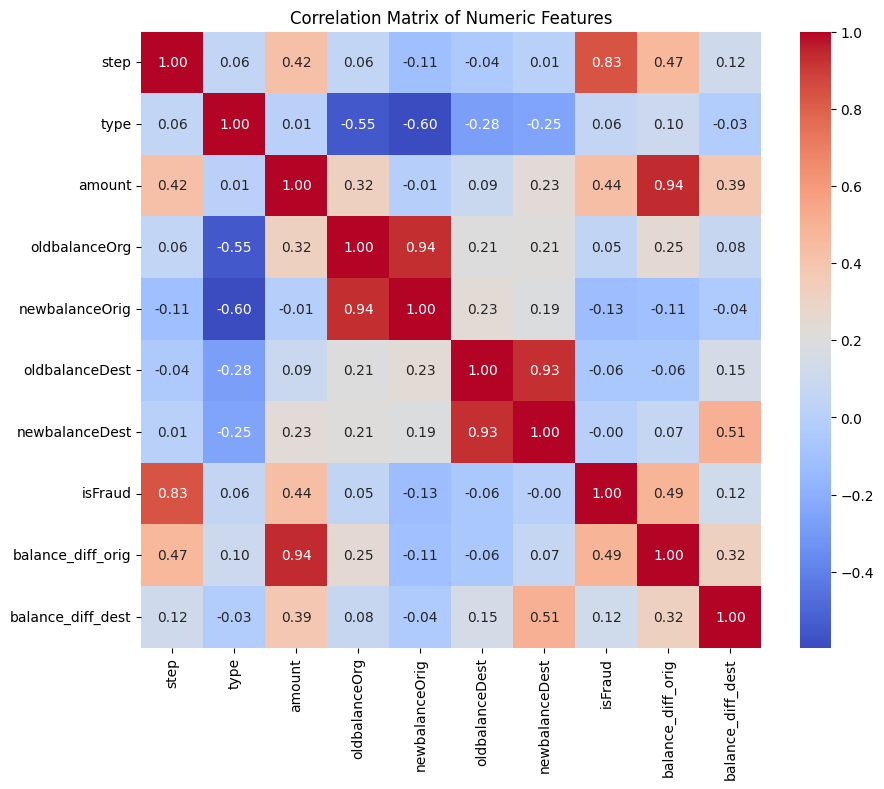

In [196]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Numeric Features")
plt.savefig("CorrelationMatrixOfNumericFeatures", dpi=300)
plt.show()

# d. ML Model Selection and Development

Training models capable of accurately detecting fraud

1. Importing Required Libraries

In [197]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [198]:
#installing xgboost
!pip install xgboost

In [199]:
#Training using Random forest
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=1000, n_jobs=-1, oob_score=True,
                       random_state=42)

In [200]:
#Training using Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_res, y_train_res)

LogisticRegression(max_iter=500, random_state=42)

In [201]:
#Training using XGBoost
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train_res, y_train_res)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:02:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [202]:
#Prediction on Test set
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [203]:
#Evaluating Random Forest
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.98      1.00      0.99       228

    accuracy                           1.00      2229
   macro avg       0.99      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229

Confusion Matrix:
[[1997    4]
 [   0  228]]
ROC AUC Score: 0.9999868486809227


In [204]:
#Evaluating Logistic Regression
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("ROC AUC Score:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2001
           1       0.98      0.93      0.95       228

    accuracy                           0.99      2229
   macro avg       0.99      0.96      0.97      2229
weighted avg       0.99      0.99      0.99      2229

Confusion Matrix:
[[1997    4]
 [  17  211]]
ROC AUC Score: 0.9861933068553442


In [205]:
#Evaluating XGBoost
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.99      1.00      0.99       228

    accuracy                           1.00      2229
   macro avg       0.99      1.00      1.00      2229
weighted avg       1.00      1.00      1.00      2229

Confusion Matrix:
[[1998    3]
 [   0  228]]
ROC AUC Score: 0.9999649298157938


# e. ML Models Performance Evaluation

In [206]:
# confusion matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

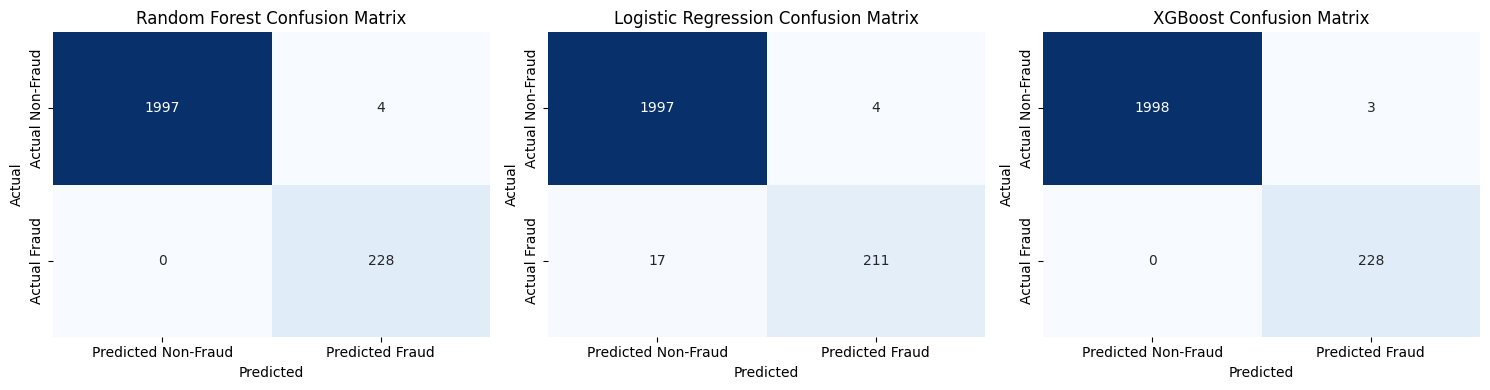

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ["Random Forest", "Logistic Regression", "XGBoost"]
cms = [cm_rf, cm_lr, cm_xgb]

# Settings
cols_per_row = 3  # All in one row
num_features = len(cms)
num_rows = 1

# Create figure
fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=cols_per_row,
    figsize=(5 * cols_per_row, 4 * num_rows)
)
axes = axes.flatten()

# Loop over each confusion matrix
for i, (model_name, cm) in enumerate(zip(models, cms)):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Non-Fraud", "Predicted Fraud"],
        yticklabels=["Actual Non-Fraud", "Actual Fraud"],
        ax=axes[i]
    )
    axes[i].set_title(f"{model_name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("ConfusionMatrices_Side_by_Side.png", dpi=300)
plt.show()

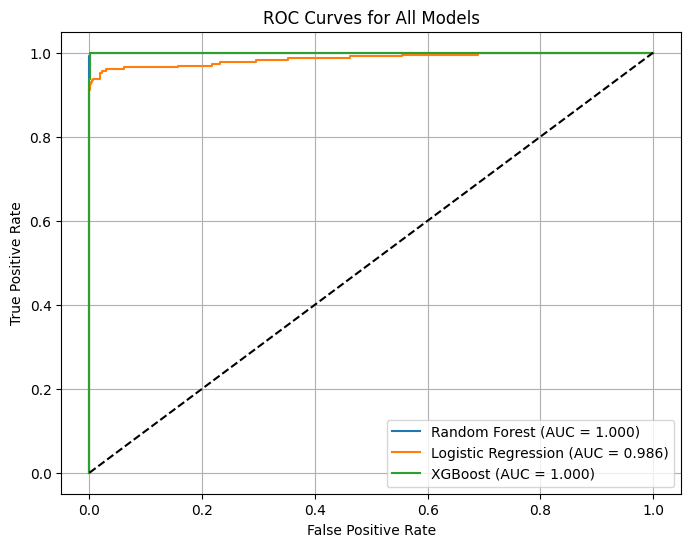

In [208]:
#AUC ROC Curves for All Models
from sklearn.metrics import roc_curve, auc

# Computing ROC curves and AUCs
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb.predict_proba(X_test)[:,1])

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotting
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.savefig("ROCCurvesforAllModels", dpi=300)
plt.show()

In [209]:
import pandas as pd

performance_summary = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "XGBoost"],
    "ROC AUC": [auc_rf, auc_lr, auc_xgb]
})

performance_summary

,Model,ROC AUC
0,Random Forest,0.999987
1,Logistic Regression,0.986193
2,XGBoost,0.999965


# f. Financial Impact Analysis

Fraud detection is valuable because every fraud we catch saves money.

False Negatives (FN): Fraud failed to detect = high cost

False Positives (FP): Legit transactions flagged as fraud = lower cost (investigation time, customer inconvenience)

So, we estimate the business cost of using the model vs. not using it.

In [210]:
#confusion matrix for the best model in our case it is Random Forest
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[1997    4]
 [   0  228]]


In [211]:
# Extract values
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

# Display
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)

True Negatives (TN): 1997
False Positives (FP): 4
False Negatives (FN): 0
True Positives (TP): 228


# 1. Total frauds

Total frauds = TP + FN

In [212]:
total_frauds = TP + FN
print("Total Actual Frauds in Test Set:", total_frauds)

Total Actual Frauds in Test Set: 228


# 2. Computing the Model Cost

Formula:

losses incurred = (FN * cost_per_fraud_missed) + (FP * cost_per_false_alarm)

In [213]:
#example
cost_per_fraud_missed = 5000
cost_per_false_alarm = 100

losses_incurred = (FN * cost_per_fraud_missed) + (FP * cost_per_false_alarm)
print("Total Cost with Model: ₹", losses_incurred)

Total Cost with Model: ₹ 400


# 3. Compute Baseline Cost (No Model)

formula

baseline_cost = total_frauds * cost_per_fraud_missed

In [214]:
total_frauds = TP + FN
baseline_cost = total_frauds * cost_per_fraud_missed
print("Baseline Cost (No Model): ₹", baseline_cost)

Baseline Cost (No Model): ₹ 1140000


# 4. Revenue saved

revenue_saved= TP * cost_per_fraud_missed

In [215]:
revenue_saved = TP * cost_per_fraud_missed
print("Revenue Saved (Frauds Prevented): ₹", revenue_saved)

Revenue Saved (Frauds Prevented): ₹ 1140000


# 5. Computing Savings

Formula:
savings = baseline_cost - losses_incurred

In [216]:
savings = baseline_cost - losses_incurred
print("Estimated Savings: ₹", savings)

Estimated Savings: ₹ 1139600


# 6. Summery

In [217]:
# If not already defined:
improvement = baseline_cost - losses_incurred

import pandas as pd

financial_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions in Test Set",
        "Total Actual Frauds",
        "Frauds Detected (TP)",
        "Frauds Missed (FN)",
        "False Positives (FP)",
        "Revenue Saved",
        "Losses Incurred",
        "Net Profit",
        "Baseline Cost (No Model)",
        "Improvement over Baseline"
    ],
    "Value": [
        len(y_test),
        total_frauds,
        TP,
        FN,
        FP,
        f"₹{revenue_saved:,}",
        f"₹{losses_incurred:,}",
        f"₹{revenue_saved - losses_incurred:,}",
        f"₹{baseline_cost:,}",
        f"₹{improvement:,}"
    ]
})

financial_summary

,Metric,Value
0,Total Transactions in Test Set,2229
1,Total Actual Frauds,228
2,Frauds Detected (TP),228
3,Frauds Missed (FN),0
4,False Positives (FP),4
5,Revenue Saved,"₹1,140,000"
6,Losses Incurred,₹400
7,Net Profit,"₹1,139,600"
8,Baseline Cost (No Model),"₹1,140,000"
9,Improvement over Baseline,"₹1,139,600"


# 7. Visualization
Bar Chart: Revenue, Losses, Net Profit

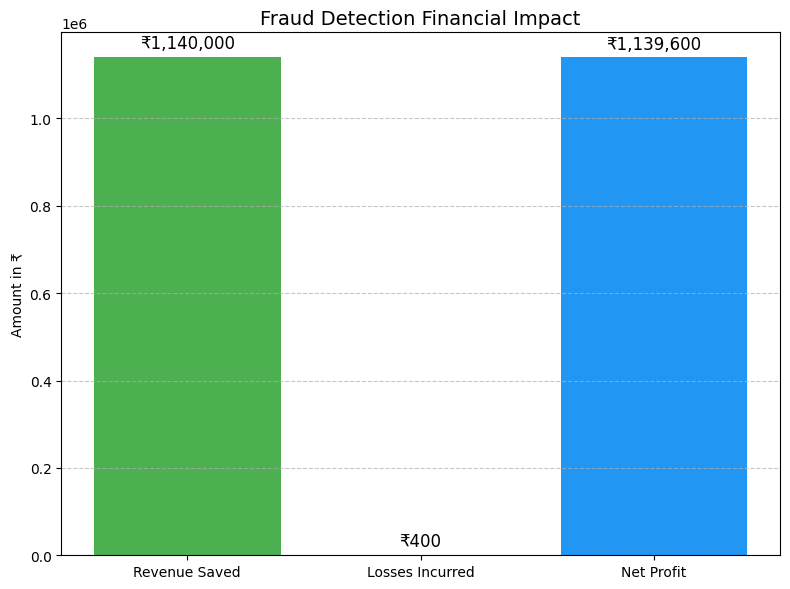

In [218]:
import matplotlib.pyplot as plt

# Data
labels = ["Revenue Saved", "Losses Incurred", "Net Profit"]
values = [revenue_saved, losses_incurred, revenue_saved - losses_incurred]
colors = ["#4CAF50", "#F44336", "#2196F3"]

plt.figure(figsize=(8,6))
bars = plt.bar(labels, values, color=colors)

# Addind value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20000, f"₹{yval:,.0f}", ha='center', fontsize=12)

plt.title("Fraud Detection Financial Impact", fontsize=14)
plt.ylabel("Amount in ₹")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("fraudDetectionFinancialImpact", dpi=300)
plt.show()

Baseline Loss vs. Model Loss

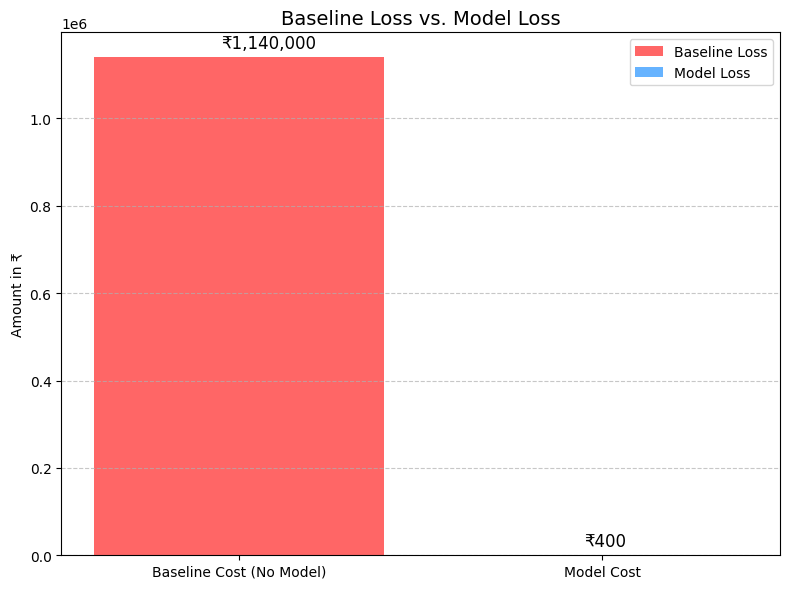

In [219]:
# Data
categories = ["Baseline Cost (No Model)", "Model Cost"]
values_baseline = [baseline_cost, 0]
values_model = [0, losses_incurred]

plt.figure(figsize=(8,6))
p1 = plt.bar(categories, values_baseline, label="Baseline Loss", color="#FF6666")
p2 = plt.bar(categories, values_model, label="Model Loss", color="#66B3FF")

# Add value labels
plt.text(-0.05, baseline_cost + 20000, f"₹{baseline_cost:,}", fontsize=12)
plt.text(0.95, losses_incurred + 20000, f"₹{losses_incurred:,}", fontsize=12)

plt.title("Baseline Loss vs. Model Loss", fontsize=14)
plt.ylabel("Amount in ₹")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("BaselineVSmodelloss", dpi=300)
plt.show()

END of the Project

Thankyou for giving me this opportunity

Riya Varghese